# BlueMesh2D → D-Flow FM Mesh Generation Example

This notebook walks through a full workflow for generating an unstructured triangular mesh (suitable for Delft3D-FM / D-Flow FM) from GEBCO global bathymetry data, using the **BlueMesh2D** toolkit.

Reference: [BlueMesh2D (develop branch)](https://github.com/GeoOcean/BlueMesh2D/tree/develop)

**Workflow overview:**
1. Define the area of interest and a "detail" sub-area that will get a finer mesh resolution.
2. Load GEBCO bathymetry/elevation data for the region.
3. Determine the appropriate coordinate reference systems (source + local UTM).
4. Extract coastline and deep-water boundary polygons from the raster data.
5. Build a depth-based mesh-size function (finer near coast/detail area, coarser offshore).
6. Generate the boundary polygon nodes/edges and run Delaunay refinement.
7. Smooth the triangulation (including a D-Flow FM specific smoothing pass).
8. Reproject mesh vertices back to geographic coordinates and interpolate depth values.
9. Export the final mesh to a D-Flow FM compatible NetCDF file (`mesh_net.nc`).

## 1. Imports

Import geometry utilities, projection helpers, mesh-size-function (hfun) builders, and the core BlueMesh2D mesh generation routines (`refine`, `smooth`, `smood`).

In [1]:
import matplotlib.pyplot as plt
from shapely.geometry import MultiPolygon, Point
from shapely.plotting import plot_polygon
import numpy as np

from bluemesh2d.geom_util.proj_util import reproject_geometry, reproject_node, get_local_utm_crs
from bluemesh2d.geom_util.poly_util import polygon_to_node_edge, resample_polygon_hfun
from bluemesh2d.geom_util.getiso import getiso_polygon
from bluemesh2d.geomesh_util.grd_util import adcirc2DFlowFM
from bluemesh2d.geomesh_util.interpolation_mesh import interpolate_from_xr
from bluemesh2d.geomesh_util.depth_field import depth_field_from_xr
from bluemesh2d.hfun_util.make_depth_hfun import make_depth_hfun
from bluemesh2d.hfun_util.smooth_and_precomput import smooth_precomput_hfun
from bluemesh2d.smood import smood
from bluemesh2d.refine import refine
from bluemesh2d.smooth import smooth

## 2. Area of Interest

Define the center point of the study area and two buffers around it:
- `Detail`: a small (0.3°) radius zone that will receive the finest mesh resolution.
- `Point_of_Interest`: a larger (4.5°) radius zone defining the overall model domain used to clip the bathymetry data.

In [2]:
Point = Point(-3, 43.4)

Detail = Point.buffer(0.3)
Point_of_Interest = Point.buffer(4.5)

## 3. Load Bathymetry Data (GEBCO 2025)

Open the GEBCO 2025 global elevation/bathymetry dataset remotely via OPeNDAP and subset it to the bounding box of `Point_of_Interest`, so only the relevant region is downloaded.

In [3]:
import xarray as xr

# Load GEBCO 2025 data from remote server
GEBCO = xr.open_dataset(
    "https://dap.ceda.ac.uk/thredds/dodsC/bodc/gebco/global/gebco_2025/ice_surface_elevation/netcdf/GEBCO_2025.nc"
)
# Extract the region of interest
GEBCO_sel = GEBCO.sel(
    lon=slice(Point_of_Interest.bounds[0], Point_of_Interest.bounds[2]),
    lat=slice(Point_of_Interest.bounds[1], Point_of_Interest.bounds[3])
)

GEBCO_sel

<xarray.Dataset> Size: 9MB
Dimensions:    (lat: 2160, lon: 2160)
Coordinates:
  * lat        (lat) float64 17kB 38.9 38.91 38.91 38.91 ... 47.89 47.89 47.9
  * lon        (lon) float64 17kB -7.498 -7.494 -7.49 ... 1.49 1.494 1.498
Data variables:
    crs        |S64 64B ...
    elevation  (lat, lon) int16 9MB ...
Attributes: (12/37)
    title:                           The GEBCO_2025 Grid - a continuous terra...
    summary:                         The GEBCO_2025 Grid is a continuous, glo...
    keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
    Conventions:                     CF-1.6, ACDD-1.3
    id:                              DOI: 10.5285/37c52e96-24ea-67ce-e063-708...
    naming_authority:                https://dx.doi.org
    ...                              ...
    geospatial_vertical_resolution:  1.0
    geospatial_vertical_positive:    up
    identifier_product_doi:          DOI: 10.5285/37c52e96-24ea-67ce-e063-708...
    references:                      DOI: 10.5285/37c52e96-24ea-67ce-e063-708...
    node_offset:                     1.0
    DODS.strlen:                     0

## 4. Source CRS

Read the CRS metadata embedded in the GEBCO dataset (EPSG code) so it can be used later for reprojection.

In [4]:
import pyproj

# Get the CRS from the dataset
crs_var = GEBCO_sel["crs"]
epsg = crs_var.attrs.get("epsg_code", None)
code = int(epsg.split(":")[-1])
crs = pyproj.CRS.from_epsg(code)

## 5. Local UTM CRS

Compute an appropriate local UTM CRS for the region of interest. Working in UTM (metric) coordinates is required for accurate distance-based mesh sizing and geometric operations.

In [5]:
lon = GEBCO_sel["lon"]
lat = GEBCO_sel["lat"]
zdat = GEBCO_sel["elevation"]

utm_crs = get_local_utm_crs(crs, lon, lat)

## 6. Extract Boundary Polygons

Derive polygons from the raster elevation data:
- `polygone_cost`: the coastline/ocean polygon (elevation ≤ 2 m), largest contiguous area kept.
- `polygone_indef`: the "indefinite depth" region (depth > 300 m), used to identify deep-water/offshore areas.

Both are reprojected to the local UTM CRS, and the domain/detail polygons are reprojected as well. The mesh generation polygon (`poly`) is the intersection of the coastline polygon with the overall domain.

In [6]:
# Extract coastline (ocean area)
polygone_cost = max(MultiPolygon(getiso_polygon(lon, lat, zdat, zmax=2.0)).geoms, key=lambda a: a.area)

# Extract indefinite depth region (depth > 300m)
polygone_indef = MultiPolygon(getiso_polygon(lon, lat, -zdat, zmax=300))
polygone_indef = max(polygone_indef.geoms, key=lambda a: a.area)  # Keep only the largest polygon

# Reproject to UTM for metric calculations
polygone_cost_UTM = reproject_geometry(polygone_cost, crs, utm_crs)
polygone_indef_UTM = reproject_geometry(polygone_indef, crs, utm_crs)
domain_UTM = reproject_geometry(Point_of_Interest, crs, utm_crs)
poly_detail_UTM = reproject_geometry(Detail, crs, utm_crs)

poly = polygone_cost_UTM.intersection(domain_UTM)

## 7. Visual Check: Coastline Polygon

Plot the GEBCO elevation raster together with the extracted coastline polygon (clipped to the point-of-interest area) to visually confirm the extraction looks correct.

(<matplotlib.patches.PathPatch at 0x7a9aadc11c90>,
 <matplotlib.lines.Line2D at 0x7a9aadd5b310>)

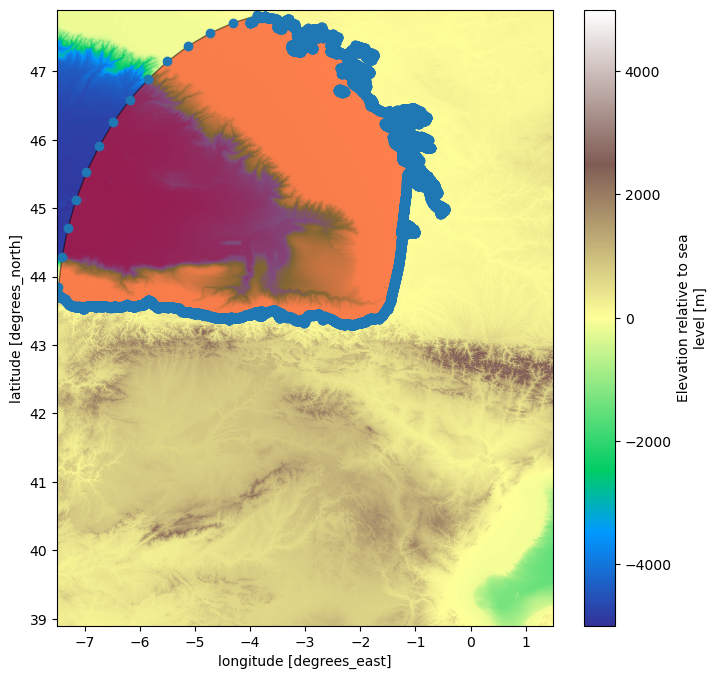

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
GEBCO_sel["elevation"].plot(cmap="terrain", ax=ax)
plot_polygon(polygone_cost.intersection(Point_of_Interest), ax=ax, facecolor="blue", edgecolor="black", alpha=0.5, label='Coastline')
plot_polygon(Detail, ax=ax, color='red', alpha=0.5, label='Detail Area')

## 8. Depth Field and Mesh-Size Function (hfun)

- `depth_field_from_xr` builds a continuous, bilinearly-interpolated depth field from the raw GEBCO grid (avoiding the "staircase" artifacts of the native ~10 m grid resolution).
- `make_depth_hfun` builds a depth-based mesh-size function: cell size ranges from `hmin` (1000 m) in general to `detail_hmin` (100 m) inside the `detail` polygon, up to `hmax` (10000 m) offshore. `slope_ncells`/`slope_step` add extra refinement along the bathymetric slope (e.g. the shelf break); set `slope_ncells=None` to disable this.

Note: the PROJ database version warning shown in the output is a local environment issue (conflicting PROJ installations) and does not affect the results here.

In [9]:
# Depth field (bilinear -> continuous depth, no 10 m staircase)
depth_field = depth_field_from_xr(GEBCO_sel, input_crs=crs, output_crs=utm_crs)

# Depth-based mesh-size function with a finer floor inside the detail area.
# slope_ncells refines the shelf break (bathymetric gradient); set it to
# None to disable the slope refinement.
hfun = make_depth_hfun(
    depth_field,
    hmin=1000.0,
    hmax=10000.0,
    detail=poly_detail_UTM,
    detail_hmin=100.0,
    slope_ncells=15,
    slope_step=500.0,
)

ERROR 1: PROJ: internal_proj_create_from_database: /home/etienne/miniconda3/envs/local_env/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.


## 9. Smooth and Precompute the hfun

Smooth the mesh-size function so it doesn't change too abruptly between neighboring cells (`max_gradient=0.1` limits the size gradient), then precompute/write it to disk (`hfun_path`) for use by the mesh generator. `plot=True` shows the resulting size-function field.

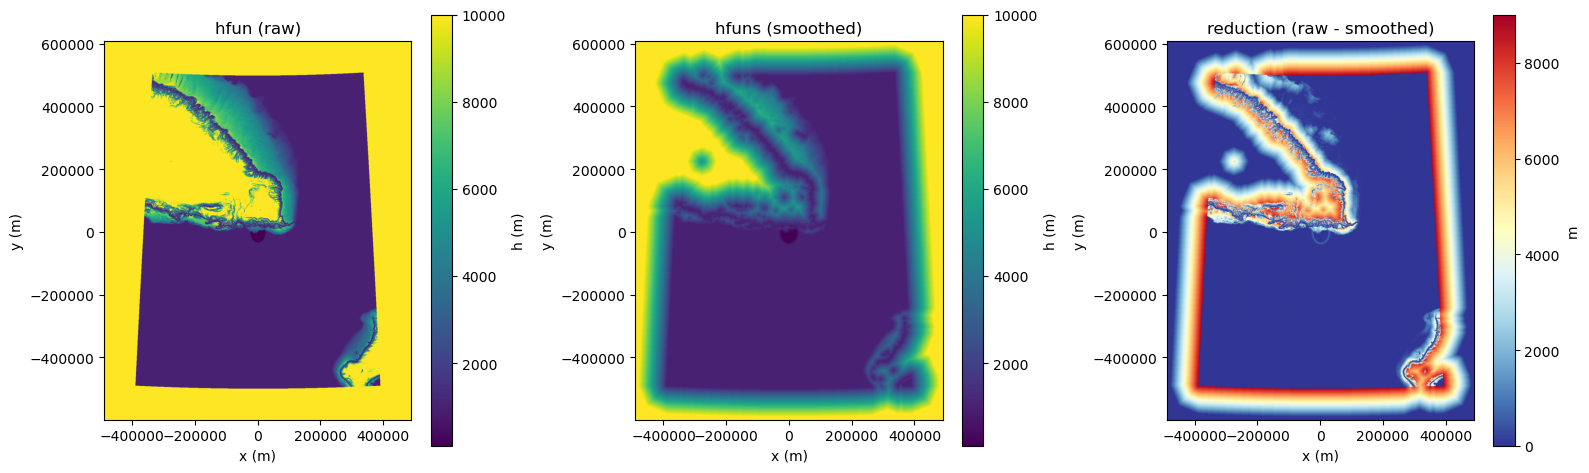

In [10]:
hfun_path = smooth_precomput_hfun(hfun, max_gradient=0.1, plot=True)

## 10. Resample Boundary and Build Node/Edge Topology

Resample the meshing polygon's boundary vertices according to the local mesh size (`hfun_path`), then convert the polygon into the `node`/`edge` arrays required as input to the Delaunay refinement step.

In [11]:
polygone_gen_UTM = resample_polygon_hfun(poly, hfun_path)

node, edge = polygon_to_node_edge(polygone_gen_UTM)

## 11. Delaunay Refinement

Generate the initial constrained Delaunay triangulation and refine it (inserting new vertices) until it satisfies the mesh-size function `hfun_path`. Outputs the mesh vertices (`vert`), edges (`etri`), triangles (`tria`), and triangle region markers (`tnum`).

In [12]:
opts_refine = {"kind": "delaunay"}

vert, etri, tria, tnum = refine(node, edge, [], opts_refine, hfun_path)


 Refine triangulation...

 -------------------------------------------------------
      |ITER.|          |CDT1(X)|          |CDT2(X)|     
 -------------------------------------------------------
          3               4269               4272
         10               4301               8293
         20               4318              40708
         30               4318             111648
         40               4318             130120
         42               4318             130152



## 12. Mesh Smoothing

Apply Laplacian-style smoothing to the triangulation to improve triangle quality (moving vertices, flipping triangles) while still honoring the mesh-size function.

In [13]:
vert, etri, tria, tnum = smooth(vert, etri, tria,  tnum, {}, hfun_path)


 Smooth triangulation...

 -------------------------------------------------------
      |ITER.|          |MOVE(X)|          |DTRI(X)|     
 -------------------------------------------------------
          0              60865             131660
          4              55633             123520
          8              45173             121040
         12              28857             119936
         16              17719             119472
         20              11206             119330
         24               9287             119280
         28               8229             119218



## 13. Delft3D-FM Specific Smoothing

Run an additional smoothing pass (`smood`) tailored to Delft3D-FM requirements, further reducing small/degenerate triangles (`N_SMALL`) and improving overall triangle angle quality (`MAX|COS(PHI)|`).

In [14]:
vert, etri, tria,  tnum = smood(vert, etri, tria, tnum)


 Smooth triangulation for Delft3D-FM computation...

 -------------------------------------------------------
      |STATE.|      |MAX|COS(PHI)| |N_SMALL| |N_ZONES|
 -------------------------------------------------------
    initial         0.302126            51          0
    outer=0         0.342730             1         56
    outer=1         0.342730             1          6
    outer=2         0.342730             1          6
    recovery=0      0.342730             0          1
    final           0.342730             0          1


## 14. Reproject Mesh Nodes to Geographic Coordinates

Convert the mesh vertex coordinates from the local UTM CRS back to the original geographic CRS (lon/lat), so they can be matched against the GEBCO grid for depth interpolation.

In [15]:
vert_geo = reproject_node(vert, utm_crs, crs)

## 15. Interpolate Depth at Mesh Nodes

Interpolate the GEBCO elevation/depth values onto each mesh vertex position, giving the bathymetry (`z`) that will be assigned to the final mesh.

In [16]:
z = interpolate_from_xr(GEBCO_sel, vert_geo)

## 16. Export to D-Flow FM NetCDF

Convert the triangulated mesh (nodes with lon/lat/depth, and triangle connectivity) into the D-Flow FM `mesh_net.nc` grid format (ADCIRC-style conversion) and write it to disk. This file can be loaded directly into Delft3D-FM / D-Flow FM.

In [17]:
ds_out = adcirc2DFlowFM(np.column_stack((vert_geo, z)), tria)

ds_out.to_netcdf("mesh_net.nc")